In [ ]:
import os
import glob
import pandas as pd

# Define the relativee path to your folder
folder_path = 'Traduction avis clients'

# Use glob to find every .xlsx file inside that folder
excel_files = glob.glob(os.path.join(folder_path, '*.xlsx'))

print(f"Found {len(excel_files)} Excel files. Starting the merge")

# Create an empty list to store our individual DataFrames
dataframes_list = []

# Loop through each file, read it, and add it to our list
for file in excel_files:
    try:
        # Read the Excel file
        temp_df = pd.read_excel(file)
        dataframes_list.append(temp_df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Concatenate all 35 DataFrames into one master DataFrame
# ignore_index=True ensures our row numbers go from 0 to the very end smoothly
df_master = pd.concat(dataframes_list, ignore_index=True)

print(f"Merge completely successful! Total combined rows: {len(df_master)}")

# Display the first few rows and the column names to see what we are working with
print("\nColumn Names found in the merged dataset:")
print(df_master.columns.tolist())

print("\nFirst 3 rows of data:")
print(df_master.head(3))

Found 35 Excel files. Starting the merge...
Merge completely successful! Total combined rows: 34435

Column Names found in the merged dataset:
['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en']

First 3 rows of data:
   note             auteur                                               avis  \
0   4.0  audurier-c-136272  La personne au téléphone était Clair et sympat...   
1   4.0      paul-a-122970  Satisfait.\n\nRéactivité, simplicité. Prix att...   
2   1.0        kitty-38517  Assureur à fuir, n assure pas ses responsabili...   

              assureur produit   type date_publication    date_exp  \
0  L'olivier Assurance    auto  train       06/10/2021  01/10/2021   
1           APRIL Moto    moto  train       09/07/2021  01/07/2021   
2            SwissLife     vie  train       15/10/2020  01/10/2020   

                                             avis_en avis_cor avis_cor_en  
0  The person on the pho

In [4]:
# Suppression des doublons exacts
df = df_master.drop_duplicates()

# Conversion des colonnes de dates au format "datetime"
# On utilise errors='coerce' pour transformer les erreurs de format en "NaT" (valeur nulle)
df['date_publication'] = pd.to_datetime(df['date_publication'], format='%d/%m/%Y', errors='coerce')
df['date_exp'] = pd.to_datetime(df['date_exp'], format='%d/%m/%Y', errors='coerce')

# Vérifier s'il y a des valeurs manquantes
print("Valeurs manquantes par colonne :\n", df.isnull().sum())

Valeurs manquantes par colonne :
 note                10330
auteur                  1
avis                    0
assureur                0
produit                 0
type                    0
date_publication        0
date_exp                0
avis_en                 2
avis_cor            33995
avis_cor_en         33999
dtype: int64


C:\Users\natha\AppData\Local\Temp\ipykernel_34412\3285174359.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_publication'] = pd.to_datetime(df['date_publication'], format='%d/%m/%Y', errors='coerce')
C:\Users\natha\AppData\Local\Temp\ipykernel_34412\3285174359.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_exp'] = pd.to_datetime(df['date_exp'], format='%d/%m/%Y', errors='coerce')


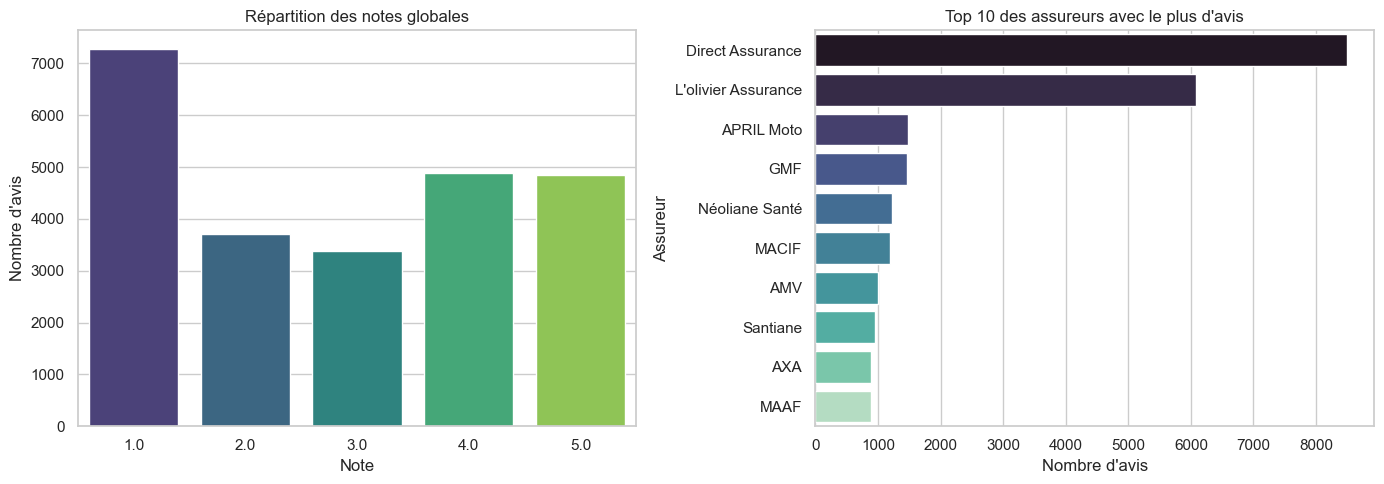

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style des graphiques
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 5))

# Graphique 1 : Répartition des notes (1 à 5)
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='note', palette='viridis')
plt.title('Répartition des notes globales')
plt.xlabel('Note')
plt.ylabel("Nombre d'avis")

# Graphique 2 : Nombre d'avis par assureur (Top 10)
plt.subplot(1, 2, 2)
top_assureurs = df['assureur'].value_counts().head(10)
sns.barplot(y=top_assureurs.index, x=top_assureurs.values, palette='mako')
plt.title('Top 10 des assureurs avec le plus d\'avis')
plt.xlabel("Nombre d'avis")
plt.ylabel('Assureur')

plt.tight_layout()
plt.show()

Plotting Top 15 Words (Unigrams)...


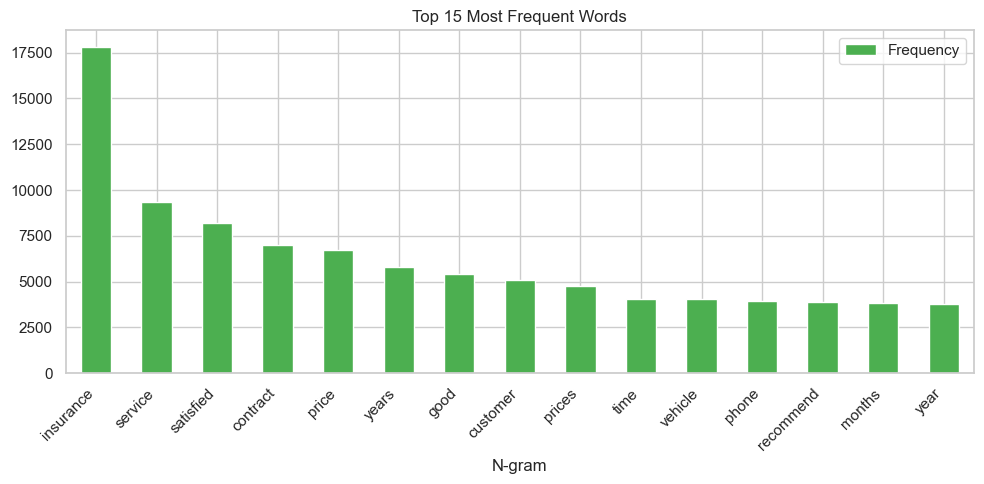

Plotting Top 15 Pairs of Words (Bigrams)...


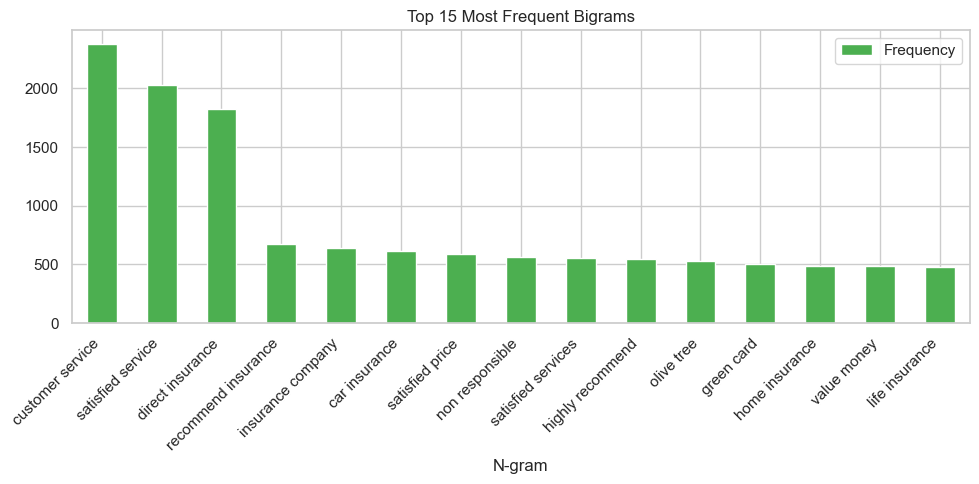

In [ ]:
## Basic Cleaning & N-Gram Visualization

import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Drop any rows where the text is completely missing
df_clean = df_master.dropna(subset=['avis_en']).copy()

def plot_ngrams(corpus, n, title, top_k=15):
    # n=1 is unigrams (single words), n=2 is bigrams (two words)
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]
    
    df_freq = pd.DataFrame(words_freq, columns=['N-gram', 'Frequency'])
    df_freq.plot(kind='bar', x='N-gram', y='Frequency', title=title, figsize=(10, 5), color='#4CAF50')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("Plotting Top 15 Words (Unigrams)...")
plot_ngrams(df_clean['avis_en'], 1, "Top 15 Most Frequent Words")

print("Plotting Top 15 Pairs of Words (Bigrams)...")
plot_ngrams(df_clean['avis_en'], 2, "Top 15 Most Frequent Bigrams")

In [9]:
!pip install pyspellchecker

  Obtaining dependency information for pyspellchecker from https://files.pythonhosted.org/packages/11/70/df4b8816f5e1aa8b46fbc2b1d104d8f5bc13ec92fb69310b35bc56ea7260/pyspellchecker-0.9.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.2 MB 320.0 kB/s eta 0:00:23
   ---------------------------------------- 0.1/7.2 MB 975.2 kB/s eta 0:00:08
   -- ------------------------------------- 0.4/7.2 MB 3.5 MB/s eta 0:00:02
   ---- ----------------------------------- 0.8/7.2 MB 5.0 MB/s eta 0:00:02
   ------ --------------------------------- 1.2/7.2 MB 5.9 MB/s eta 0:00:02
   ------- -------------------------------- 1.4/7.2 MB 5.7 MB/s eta 0:00:02
   -------- ------------------------------- 1.6/7.2 MB 5.7 MB/s eta 0:00:01
   ---------- ----------------------------- 1.9/7.2 MB 6.0 MB/s eta 0:00:01
   ----------- ---------------------------- 2.1/7.2 MB 5.9 MB/s eta 0:00:01
   ------------- -------------

In [10]:
import re
import pandas as pd
from spellchecker import SpellChecker
from tqdm import tqdm

# Initialize tqdm for pandas to get our progress bar
tqdm.pandas()

print("Loading French spelling dictionary from pyspellchecker...")
# This library is great because the dictionary is already packed inside it!
spell_fr = SpellChecker(language='fr')

def correct_french_spelling(text):
    # Skip empty rows
    if pd.isna(text) or not isinstance(text, str):
        return text
        
    # Extract words using the spellchecker's built-in tokenizer
    words = spell_fr.split_words(text)
    
    # Find only the words that are misspelled (this makes it much faster!)
    misspelled = spell_fr.unknown(words)
    
    corrected_text = text
    for word in misspelled:
        # Get the most likely correction
        correction = spell_fr.correction(word)
        
        # If a correction exists and it's different from the original word
        if correction and correction != word:
            # Use regex to carefully replace only the exact word, preserving case and punctuation
            corrected_text = re.sub(rf'\b{re.escape(word)}\b', correction, corrected_text, flags=re.IGNORECASE)
            
    return corrected_text

print("Applying spelling correction to the first 100 rows...")
# We are still testing on the first 100 rows just to make sure you like the output!
df_clean['avis_cor'] = df_clean['avis'].head(100).progress_apply(correct_french_spelling)

print("\n--- Example Comparison ---")
print("Original:", df_clean['avis'].iloc[2])
print("Corrected:", df_clean['avis_cor'].iloc[2])

Loading French spelling dictionary from pyspellchecker...
Applying spelling correction to the first 100 rows...


100%|██████████| 100/100 [01:50<00:00,  1.11s/it]


--- Example Comparison ---
Original: Assureur à fuir, n assure pas ses responsabilités! Son agent d’assurance (reflex finance) de Nice à fait de faux contrats, aucun accompagnement, rien, obligé de faire un procès !!
 Je vais les pourrir sur le Web!!
Corrected: Assureur à fuir, un assure pas ses responsabilités! Son agent de’assurance (reflet finance) de nièce à fait de faux contrats, aucun accompagnement, rien, obligé de faire un procès !!
 Je vais les pourrir sur le de!!
